# Imports

In [12]:
import kagglehub
import os, glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Download the latest version

In [13]:
path = kagglehub.dataset_download("zynicide/wine-reviews")
print("Path to dataset files:", path)

csvs = glob.glob(os.path.join(path, "**", "*.csv"), recursive=True)

print("CSV to be used:", csvs[0]) # Use the first CSV file found

raw_data = pd.read_csv(csvs[0], index_col=0) # Load the CSV file into a DataFrame

Path to dataset files: /home/dagh/.cache/kagglehub/datasets/zynicide/wine-reviews/versions/4
CSV to be used: /home/dagh/.cache/kagglehub/datasets/zynicide/wine-reviews/versions/4/winemag-data_first150k.csv


# Exploratory analysis

## Overview of raw data

In [14]:
print(raw_data.describe())  # Get summary statistics of numerical columns  
print("-------------------------------------------")
print(raw_data.info())          # Get info about data types and non-null counts 

              points          price
count  150930.000000  137235.000000
mean       87.888418      33.131482
std         3.222392      36.322536
min        80.000000       4.000000
25%        86.000000      16.000000
50%        88.000000      24.000000
75%        90.000000      40.000000
max       100.000000    2300.000000
-------------------------------------------
<class 'pandas.core.frame.DataFrame'>
Index: 150930 entries, 0 to 150929
Data columns (total 10 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   country      150925 non-null  object 
 1   description  150930 non-null  object 
 2   designation  105195 non-null  object 
 3   points       150930 non-null  int64  
 4   price        137235 non-null  float64
 5   province     150925 non-null  object 
 6   region_1     125870 non-null  object 
 7   region_2     60953 non-null   object 
 8   variety      150930 non-null  object 
 9   winery       150930 non-null  object 
dtypes: fl

## Shape and columns

In [15]:
print("Raw data shape:", raw_data.shape)
print("Raw data columns:", raw_data.columns.tolist())

Raw data shape: (150930, 10)
Raw data columns: ['country', 'description', 'designation', 'points', 'price', 'province', 'region_1', 'region_2', 'variety', 'winery']


## First rows

In [16]:
print("First 5 rows of raw data:")
print(raw_data.head())# Display first 5 rows of the dataset

First 5 rows of raw data:
  country                                        description  \
0      US  This tremendous 100% varietal wine hails from ...   
1   Spain  Ripe aromas of fig, blackberry and cassis are ...   
2      US  Mac Watson honors the memory of a wine once ma...   
3      US  This spent 20 months in 30% new French oak, an...   
4  France  This is the top wine from La Bégude, named aft...   

                            designation  points  price        province  \
0                     Martha's Vineyard      96  235.0      California   
1  Carodorum Selección Especial Reserva      96  110.0  Northern Spain   
2         Special Selected Late Harvest      96   90.0      California   
3                               Reserve      96   65.0          Oregon   
4                            La Brûlade      95   66.0        Provence   

            region_1           region_2             variety  \
0        Napa Valley               Napa  Cabernet Sauvignon   
1               To

## Null count per column

In [17]:
print(raw_data.isnull().sum())  # Check for missing values in each column

country            5
description        0
designation    45735
points             0
price          13695
province           5
region_1       25060
region_2       89977
variety            0
winery             0
dtype: int64


## Skewness of price column

In [18]:
skewness = raw_data['price'].skew()
print('Skeness: ', skewness)  # Check skewness of the 'price' column

Skeness:  11.82010013395079


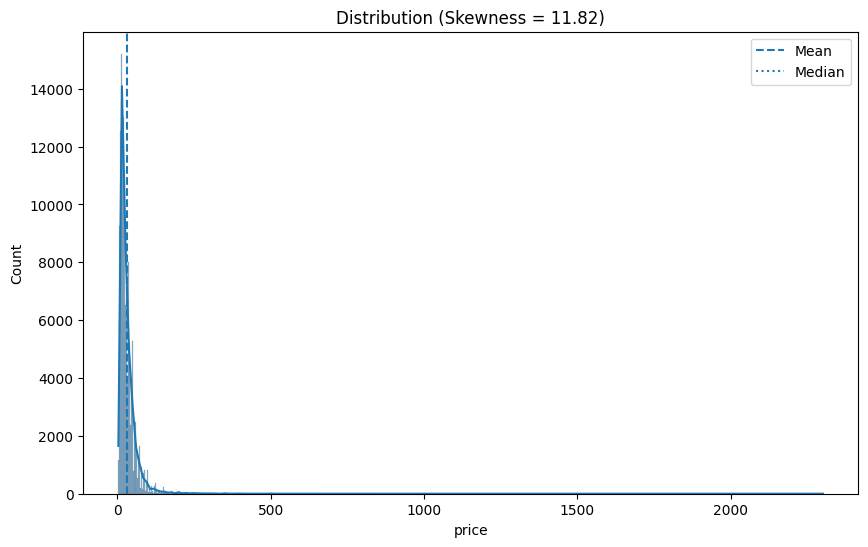

In [20]:
plt.figure(figsize=(10, 6))
sns.histplot(raw_data['price'], kde=True)
plt.axvline(np.mean(raw_data['price']), linestyle='--', label='Mean')
plt.axvline(np.median(raw_data['price']), linestyle=':', label='Median')

plt.title(f"Distribution (Skewness = {skewness:.2f})")
plt.legend()
plt.show()

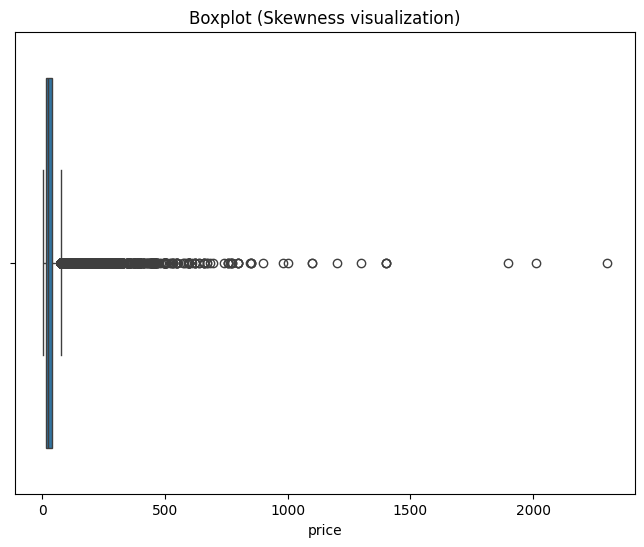

In [22]:
plt.figure(figsize=(8, 6)   )
sns.boxplot(x=raw_data['price'])
plt.title("Boxplot (Skewness visualization)")
plt.show()
